# Customer Retention & Churn Analysis
## Task 2 - Data science & Analytics Internship

In this project, I am analysing customer data to understand why customers are leaving (churning) and what factors affect customer retention.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries imported!')

Libraries imported!


## Step 2: Loading the Dataset
I am loading the Telco Customer Churn CSV file to begin my analysis

In [2]:
df = pd.read_csv('Telco-customer-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Understanding the Dataset
Let me check the size, column names and dataa types

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Step 4: Cleaning the Dataset
TotalCharge column has some empty values, so I am converting it to numeric and removing null rows

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print('clean data shape:', df.shape)

clean data shape: (7032, 21)


Step 5: Customer Churn Distribution 
Let me visulize how many customers churned vs retained.

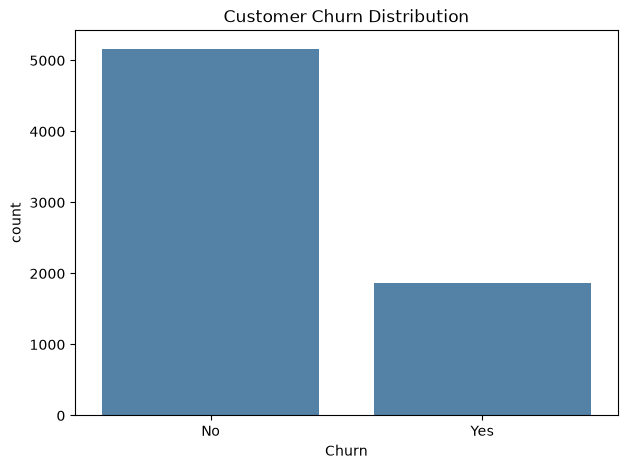

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x='Churn', data=df, color='steelblue')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('count')
plt.show()

## Step 6: Churn by Contract Type
Let me check which contract type has the highest churn rate

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


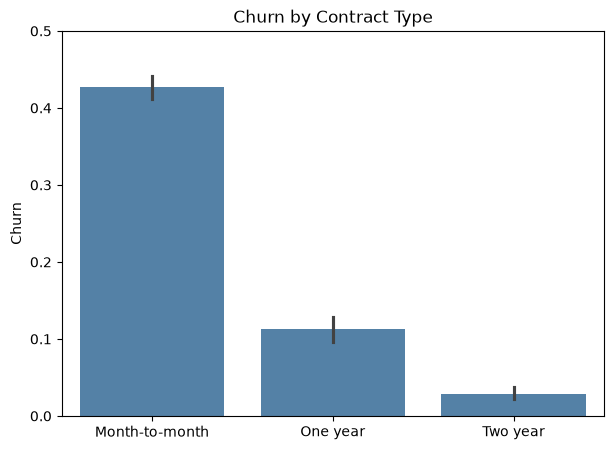

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(x='Contract', y='Churn', data=df, color='steelblue',
            order=['Month-to-month', 'One year', 'Two year'])
plt.title('Churn by Contract Type')
plt.xlabel('')
plt.ylabel('Churn')
plt.ylim(0, 0.5)
plt.show()

## Step 8: Monthly charges vs Churn
Let me check if higher monthly charges lead to more churn

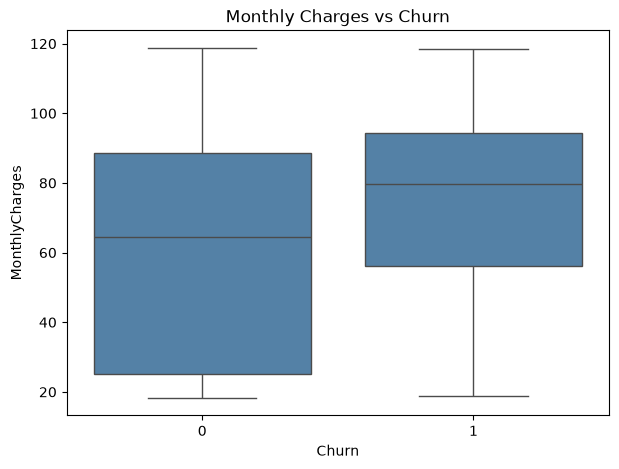

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, color='steelblue')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('MonthlyCharges')
plt.show()

## Step 9: Churn vs Customer Tenure
Let me check if long-term customers are less likely to churn

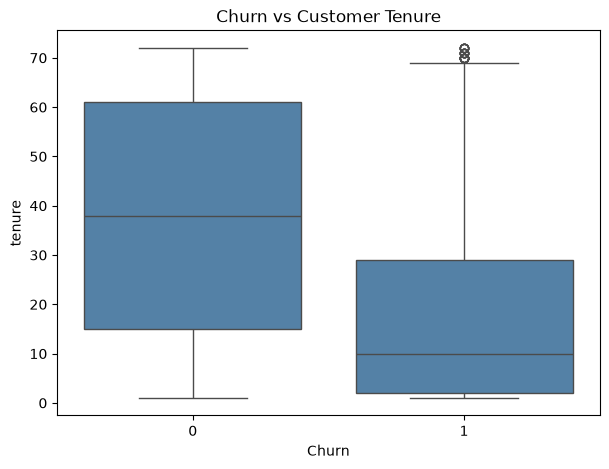

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='tenure', data=df, color='steelblue')
plt.title('Churn vs Customer Tenure')
plt.xlabel('Churn')
plt.ylabel('tenure')
plt.show()

## Step 10: Key Insights & Conclusion

In [16]:
print('Churn Rate by Contract Type:')
print(df.groupby('Contract')['Churn'].mean().round(3))

print('\nAverage Tenure:')
print(df.groupby('Churn')['tenure'].mean().round(1))

print('\nAverage Monthly Charges:')
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

Churn Rate by Contract Type:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

Average Tenure:
Churn
0    37.7
1    18.0
Name: tenure, dtype: float64

Average Monthly Charges:
Churn
0    61.31
1    74.44
Name: MonthlyCharges, dtype: float64


## Conclusion

- Around 26% of customers churned
- Month-to-month contract customers churn the most (43%)
- One year contract churn rate is only 11%
- Two year contract churn rate is very low (3%)
- Customers who churned had lower tenure (left early)
- Customers who churned paid higher monthly charges
- Recommendation: Encourage customers to take long 
  term contracts and reduce monthly charges to 
  improve customer retention